# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [6]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [7]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Double check some datatypes, and for nulls and duplicates:

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [12]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [13]:
df.Segment.unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [14]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [15]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [16]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [17]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [18]:
query2 = """ SELECT
    c.customer_name,
    ROUND(SUM(od.sales),2) AS total_sales
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_name
ORDER BY total_sales DESC
LIMIT 10
 """
result2 = pd.read_sql(query2, conn)
result2

,customer_name,total_sales
0,Ken Lonsdale,155927.52
1,Sanjit Engle,134303.82
2,Clay Ludtke,130566.55
3,Adrian Barton,130262.14
4,Sanjit Chand,127281.01
5,Sean Miller,125215.25
6,Edward Hooks,123730.56
7,Greg Tran,118201.20
8,Seth Vernon,114709.50
9,John Lee,107799.15


### Which product categories and subcategories are the most profitable overall?

In [19]:
query3 = """ SELECT *
FROM(
    SELECT 
        p.category,
        p.subcategory,
        SUM(od.profit) AS total_profit,
        RANK() OVER (
        PARTITION BY p.category
        ORDER BY SUM(profit) DESC) 
    AS profit_rank
FROM products p
JOIN order_details od
    ON p.product_id = od.product_id
GROUP BY p.category, p.subcategory 
) ranked
WHERE profit_rank = 1"""
result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,total_profit,profit_rank
0,Furniture,Chairs,26707.6526,1
1,Office Supplies,Paper,36994.5335,1
2,Technology,Copiers,55617.8249,1


### What is the average discount given per category?

In [20]:
query4 = """ SELECT
    p.category,
  ROUND(
    SUM(od.discount * od.quantity) 
    / SUM(od.quantity) * 100,
    2
) AS average_discount
FROM products p
JOIN order_details od
    ON p.product_id = od.product_id
GROUP BY p.category
  """
result4 = pd.read_sql(query4, conn)
result4

,category,average_discount
0,Furniture,17.09
1,Office Supplies,15.95
2,Technology,13.17


### Which states or regions contribute the most to total sales?

In [21]:
query5 = """  SELECT *
FROM(
    SELECT 
        c.region,
        c.state,
        SUM(od.sales) AS total_sales,
        RANK() OVER (
        PARTITION BY c.region
        ORDER BY SUM(od.sales) DESC) 
    AS sales_rank
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_details od
    ON o.order_id = od.order_id
GROUP BY c.region, c.state
) ranked
WHERE sales_rank = 1 
ORDER BY total_sales DESC"""
result5 = pd.read_sql(query5, conn)
result5

,region,state,total_sales,sales_rank
0,West,California,3.314838e+06,1
1,East,New York,1.859365e+06,1
2,Central,Texas,1.547926e+06,1
3,South,Florida,6.356378e+05,1


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [22]:
query6 = """ SELECT
    COUNT(order_id)
FROM orders
WHERE ship_date > DATE(order_date, '+3 days') """

result6 = pd.read_sql(query6, conn)
result6

,COUNT(order_id)
0,3902


### Which month or year had the highest total sales?

In [27]:
query7 = """ SELECT *
FROM(
    SELECT 
        strftime('%Y', o.order_date) AS order_year,
        strftime('%m', o.order_date) AS order_month,
        SUM(od.sales) AS total_sales,
        RANK() OVER (
        PARTITION BY strftime('%Y', o.order_date)
        ORDER BY SUM(od.sales) DESC) 
    AS sales_rank
FROM orders o
JOIN order_details od
    ON o.order_id = od.order_id
GROUP BY 
    strftime('%Y', o.order_date),
    strftime('%m', o.order_date)
) ranked
WHERE sales_rank = 1 
ORDER BY total_sales DESC"""

result7 = pd.read_sql(query7, conn)
result7

,order_year,order_month,total_sales,sales_rank
0,2014,11,112326.4710,1
1,2013,12,97237.4170,1
2,2011,09,81777.3508,1
3,2012,11,75972.5635,1


### What are the most frequently ordered products?

In [30]:
query8 = """SELECT
    p.product_name,
    SUM(od.quantity) AS total_sold 
FROM products p
JOIN order_details od
    ON p.product_id = od.product_id
GROUP BY p.product_name
ORDER BY total_sold DESC
    """
result8 = pd.read_sql(query8, conn)
result8

,product_name,total_sold
0,Staples,876
1,Logitech P710e Mobile Speakerphone,75
2,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,75
3,KI Adjustable-Height Table,74
4,Storex Dura Pro Binders,71
...,...,...
1836,Xerox 20,1
1837,Penpower WorldCard Pro Card Scanner,1
1838,Global Enterprise Series Seating Low-Back Swiv...,1
1839,"Bush Saratoga Collection 5-Shelf Bookcase, Han...",1


### Which customers placed more than 5 orders total?

In [37]:
query9 = """ SELECT
    c.customer_name,
    COUNT(o.order_id) AS order_total
FROM customers c
JOIN orders o 
    ON c.customer_id = o.customer_id
GROUP BY c.customer_name
HAVING order_total > 5
      """
result9 = pd.read_sql(query9, conn)
result9

,customer_name,order_total
0,Aaron Bergman,9
1,Aaron Hawkins,49
2,Aaron Smayling,49
3,Adam Bellavance,64
4,Adam Hart,100
...,...,...
742,Xylona Preis,121
743,Yana Sorensen,64
744,Yoseph Carroll,25
745,Zuschuss Carroll,169


### What’s the profit margin (profit ÷ sales) by category or segment?

In [39]:
query10 = """ SELECT
    p.category,
    ROUND(SUM(od.profit) / NULLIF(SUM(od.sales), 0) * 100, 2) AS profit_margin_pct
FROM products p
JOIN order_details od
    ON p.product_id = od.product_id
GROUP BY p.category
ORDER BY profit_margin_pct DESC; """
result10 = pd.read_sql(query10, conn)
result10

,category,profit_margin_pct
0,Technology,17.17
1,Office Supplies,17.12
2,Furniture,2.63


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

In [ ]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


C:\Users\RLPKi\AppData\Local\Temp\ipykernel_18704\2339708169.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


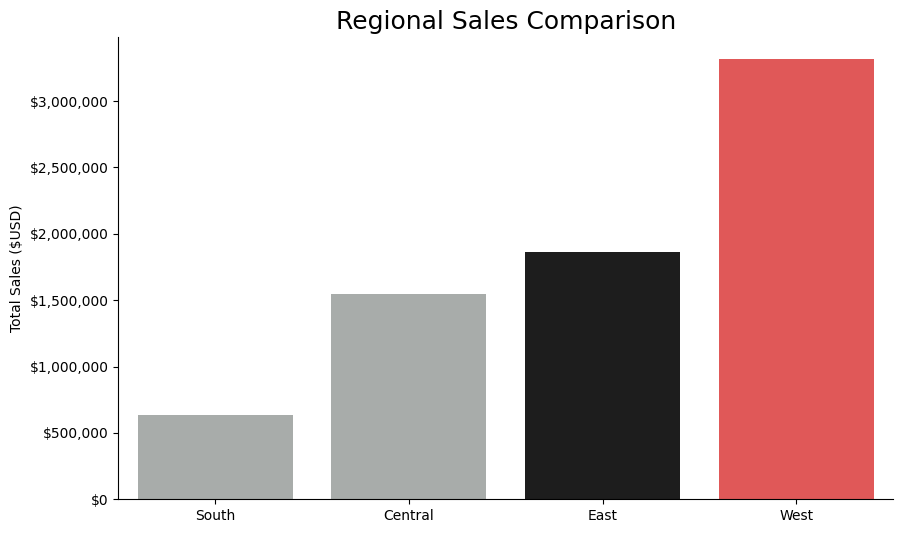

In [ ]:
# visualization one code here

plt.figure(figsize=(10,6))

result5 = result5.sort_values("total_sales") 

colors = ["#a7adaa", "#a7adaa", "#1d1d1d", "#f74141"]

sns.barplot(
    data=result5,
    x='region',
    y='total_sales',
    palette=colors
)

plt.title('Regional Sales Comparison', fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

plt.ticklabel_format(style='plain', axis='y')

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

sns.despine()
plt.show()

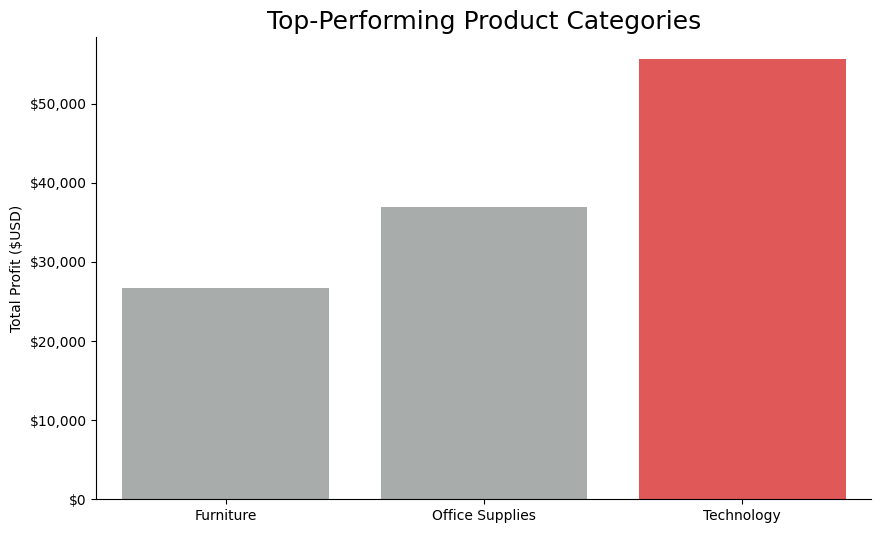

In [55]:
# visualization two code here

plt.figure(figsize=(10,6))

colors = ["#a7adaa", "#a7adaa", "#f74141"]

sns.barplot(
    data=result3,
    x='category',
    y='total_profit',
    palette=colors,
    hue='category',
    legend=False
)

plt.title('Top-Performing Product Categories', fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Profit ($USD)')

plt.ticklabel_format(style='plain', axis='y')

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

sns.despine()
plt.show()

C:\Users\RLPKi\AppData\Local\Temp\ipykernel_18704\922858213.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


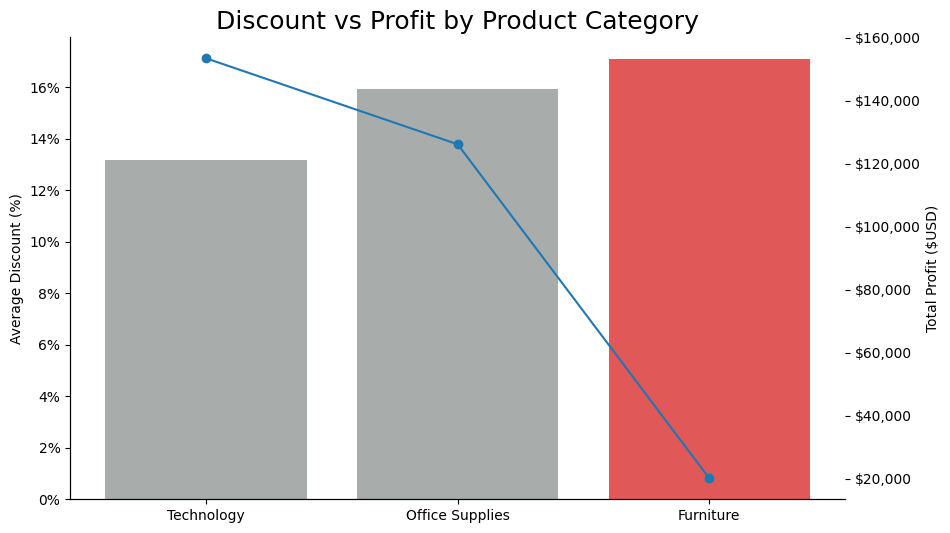

In [58]:
# visualization three code here

query_combined = """
SELECT
    p.category,
    ROUND(
        SUM(od.discount * od.quantity) 
        / NULLIF(SUM(od.quantity), 0) * 100,
        2
    ) AS average_discount,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM products p
JOIN order_details od
    ON p.product_id = od.product_id
GROUP BY p.category
"""

combined_df = pd.read_sql(query_combined, conn)
combined_df

plt.figure(figsize=(10,6))

# Sort by discount
combined_df = combined_df.sort_values("average_discount")

# Highlight highest discount category
colors = ["#a7adaa"] * len(combined_df)
colors[-1] = "#f74141"

# Barplot for discount
ax1 = sns.barplot(
    data=combined_df,
    x='category',
    y='average_discount',
    palette=colors
)

plt.ylabel('Average Discount (%)')
plt.xlabel(None)

# Format discount axis
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%')
)

# Second axis for profit
ax2 = ax1.twinx()
ax2.plot(
    combined_df['category'],
    combined_df['total_profit'],
    marker='o'
)

ax2.set_ylabel('Total Profit ($USD)')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.title('Discount vs Profit by Product Category', fontsize=18)

sns.despine()
plt.show()


In [ ]:
# visualization four code here